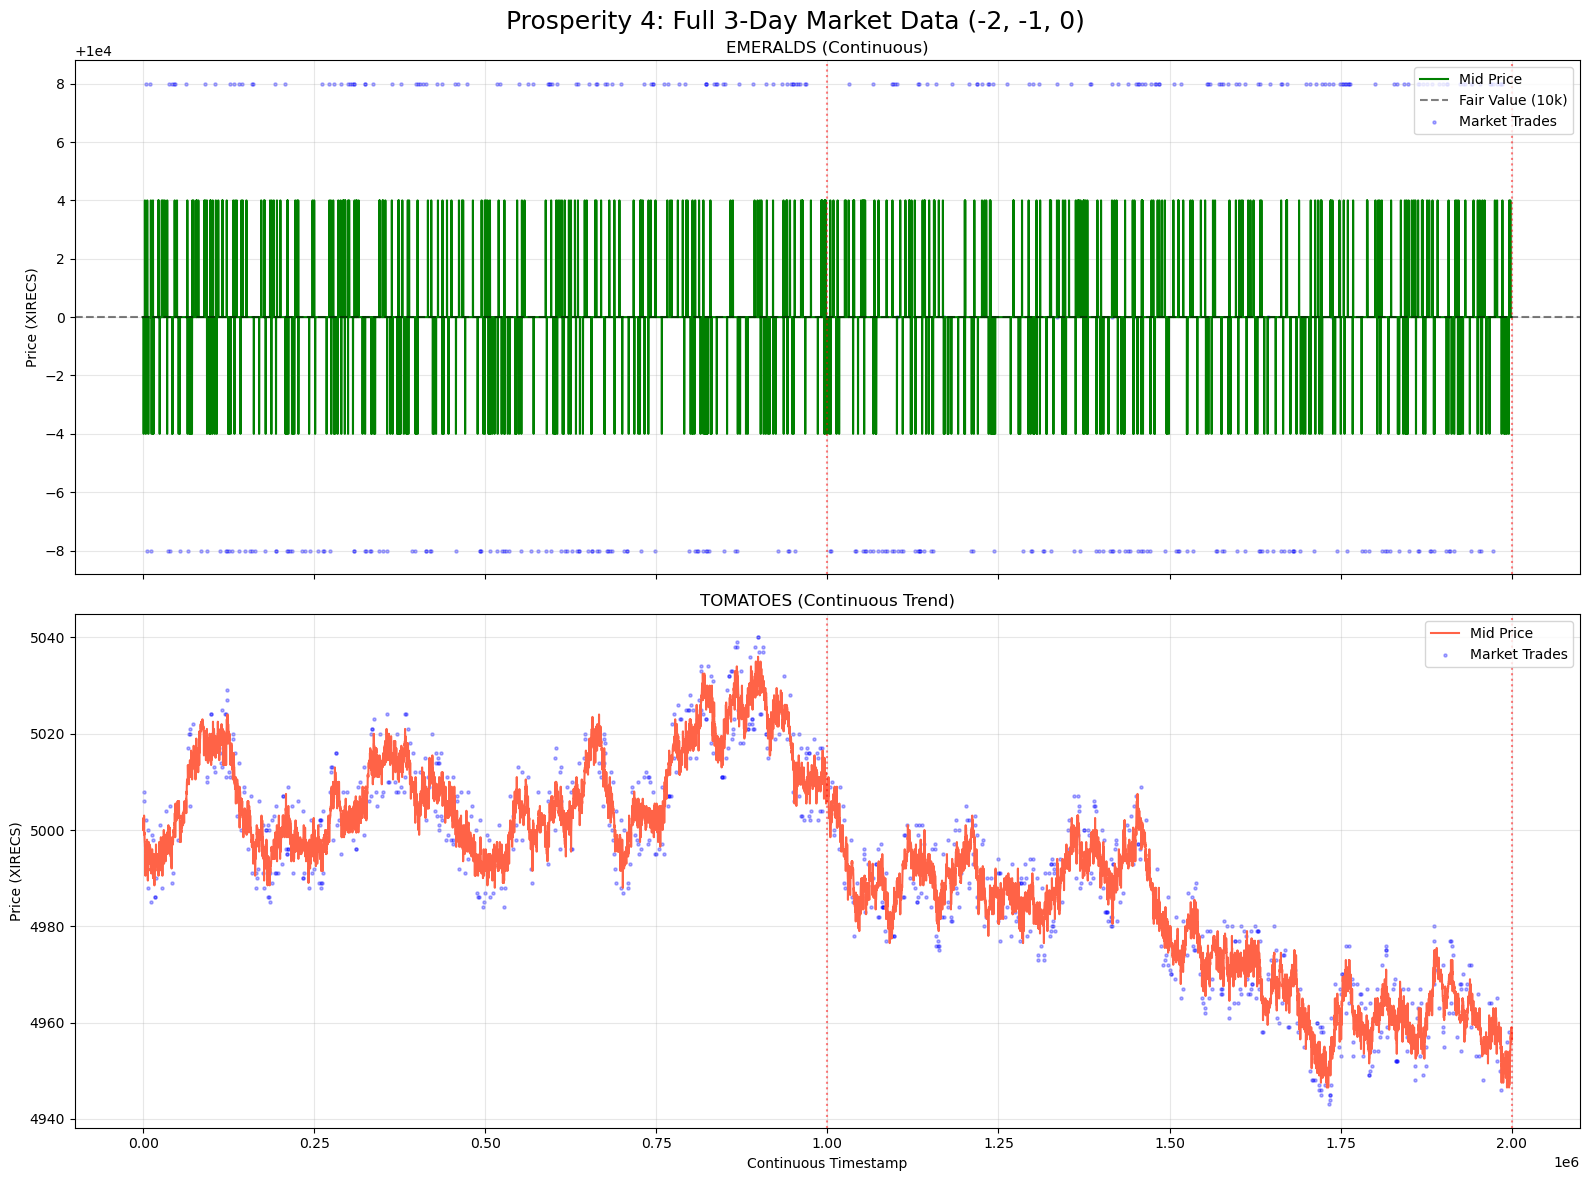

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Define the path to your data folder
data_folder = "/home/chesy/Projects/imc-prosperity-4-backtester/prosperity4bt/resources/round0/"

# 2. We will stitch these days together
days = [-2, -1]
all_prices = []
all_trades = []

# 3. Load and offset the timestamps so they form one continuous timeline
for i, day in enumerate(days):
    price_file = f"{data_folder}/prices_round_0_day_{day}.csv"
    trade_file = f"{data_folder}/trades_round_0_day_{day}.csv"
    
    # Each day is 1,000,000 timestamps long. 
    # We offset Day -2 by 0, Day -1 by 1M, Day 0 by 2M
    time_offset = i * 1000000 
    
    # Load Prices
    if os.path.exists(price_file):
        df_price = pd.read_csv(price_file, sep=";")
        df_price['timestamp'] += time_offset
        all_prices.append(df_price)
        
    # Load Trades (Market Trades)
    if os.path.exists(trade_file):
        df_trade = pd.read_csv(trade_file, sep=";")
        df_trade['timestamp'] += time_offset
        all_trades.append(df_trade)

# Combine the lists into massive dataframes
df_prices_full = pd.concat(all_prices, ignore_index=True)
df_trades_full = pd.concat(all_trades, ignore_index=True) if all_trades else pd.DataFrame()

# Separate the products
emeralds = df_prices_full[df_prices_full['product'] == 'EMERALDS']
tomatoes = df_prices_full[df_prices_full['product'] == 'TOMATOES']

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Prosperity 4: Full 3-Day Market Data (-2, -1, 0)', fontsize=18)

# 1. EMERALDS PLOT
ax1.plot(emeralds['timestamp'], emeralds['mid_price'], label='Mid Price', color='green', linewidth=1.5)
ax1.axhline(10000, color='black', linestyle='--', alpha=0.5, label='Fair Value (10k)')

# Add Market Trades to Emeralds if they exist
if not df_trades_full.empty:
    em_trades = df_trades_full[df_trades_full['symbol'] == 'EMERALDS']
    # Plot trades where someone bought (price usually near ask)
    ax1.scatter(em_trades['timestamp'], em_trades['price'], color='blue', s=5, alpha=0.3, label='Market Trades')

ax1.set_title('EMERALDS (Continuous)')
ax1.set_ylabel('Price (XIRECS)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 2. TOMATOES PLOT
ax2.plot(tomatoes['timestamp'], tomatoes['mid_price'], label='Mid Price', color='tomato', linewidth=1.5)

# Add Market Trades to Tomatoes if they exist
if not df_trades_full.empty:
    tom_trades = df_trades_full[df_trades_full['symbol'] == 'TOMATOES']
    ax2.scatter(tom_trades['timestamp'], tom_trades['price'], color='blue', s=5, alpha=0.3, label='Market Trades')

ax2.set_title('TOMATOES (Continuous Trend)')
ax2.set_xlabel('Continuous Timestamp')
ax2.set_ylabel('Price (XIRECS)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Draw vertical lines to show where the days change
for offset in [1000000, 2000000]:
    ax1.axvline(offset, color='red', linestyle=':', alpha=0.5)
    ax2.axvline(offset, color='red', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()